In [18]:
# import libraries and dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tpax = pd.read_csv("Titanic-Dataset.csv")
tpax.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [19]:
#checcking the missing values

tpax.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [20]:
# fill the missing values

tpax['Age'] = tpax['Age'].fillna(tpax['Age'].median())
tpax.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Handling Missing Values - Age
- The Age column consist of 177 missing values
- Missing values were loaded in the list with the help of median age
- Median was selected due to its responsbilities of managing and controlling outliers superior to mean

In [21]:
#drop cabin column

tpax = tpax.drop(columns=['Cabin'])

In [22]:
tpax.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

## Dropping Cabin Column
- The Cabin column consist of 687 missing values
- The column was declined because most values were absent 
- Deleting the column assists to enhance the better data governance and simplifies analysis

In [23]:
# Fill Missing Embarked Values

tpax['Embarked'] = tpax['Embarked'].fillna(tpax['Embarked'].mode()[0])

In [24]:
tpax.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [25]:
tpax.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


## Managing Missing Values - Embarked
- The Embarked column consist of 2 missing values which were occupied utilizing the mode (most common value)
- Post preinterpretation, the dataset encompassed no missing values

## Dataset Information
- The cleaned dataset consist of 891 passenger records and 11 columns
- Post preinterpretation, no missing values are identified and prevailed
- The dataset consist both numerical and categorical data
- Significant variables cotains survival status, gender, passenger class, age, and fare

In [26]:
# Identifying more survival status: males or females?

tpax.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

## Survival based on Gender
- Female passengers got a highest survival rate of around 74% as “Women and children first” rescue policy was implemented.
- Male passengers got a survival rate of around 19%
- Females were considerably high volumn probability to survive than males. 
- This considers that gender played a crucial role in survival chances

In [27]:
# Did passenger class affect survival chances?

tpax.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

## Survival by Passenger Class
- Passenger class had a great influnece on survival chances
- First-class passengers had the highest survival rate (~63%)
- Third-class passengers had the lowest survival rate (~24%)
- The main reason for the high survival rate of first-class passengers was that they obtained premium cabin spots, instant access to lifeboats, and higher social priority.
- This recommends that wealth and social status influenced survival during the disaster

In [28]:
# Finding survival rate by age group?

tpax['AgeGroup'] = pd.cut(tpax['Age'],
                        bins=[0, 12, 19, 35, 60, 100],
                        labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])

In [30]:
tpax.groupby('AgeGroup')['Survived'].mean()

/var/folders/th/4yrtg3v95hb741tkr_p1p5380000gn/T/ipykernel_41155/3393598498.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tpax.groupby('AgeGroup')['Survived'].mean()


AgeGroup
Child          0.579710
Teen           0.410526
Young Adult    0.352941
Adult          0.400000
Senior         0.227273
Name: Survived, dtype: float64

## Survival by Age Group
- Children has obtained the highest survival rate (~58%)
- Seniors has got the lowest survival rate (~23%)
- Younger passengers were liable to survive compared to older passengers
- Throughout the Titanic disaster, age played a crucial role in survival chances

# Visualizations

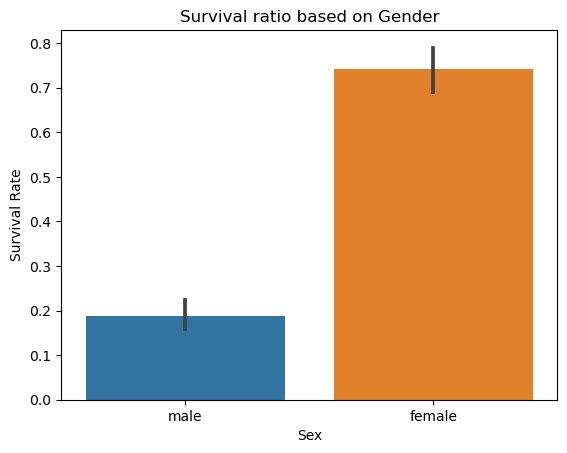

In [32]:
# Bar chart of survival by gender

import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='Sex', y='Survived', data=tpax)

plt.title("Survival ratio based on Gender")
plt.ylabel("Survival Rate")
plt.show()

## Visualization: Survival by Gender
- The bar chart explicitily display that female passengers had a much higher survival rate than male passengers
- Female survival rate was around 74%, while male survival rate was around 19%
- Gender was consider the major and strongest cause influencing survival

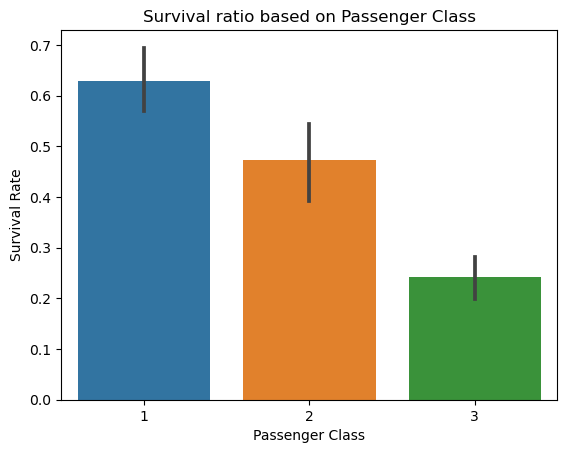

In [33]:
#Bar chart of survival by class

sns.barplot(x='Pclass', y='Survived', data=tpax)

plt.title("Survival ratio based on Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

## Survival by Passenger Class
- First-class passengers produced Maximum survival rate
- Third-class passengers produced minimum survival rate
- The graph represends that passenger class vitally affecting the survival chances
- Wealth and social status may have affected access to rescue opportunities

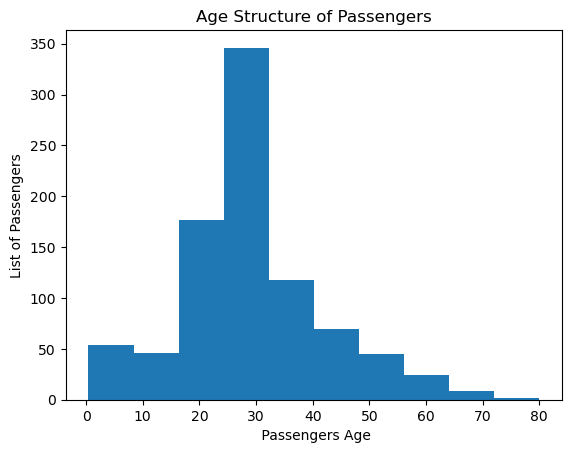

In [36]:
# Histogram of passenger ages

plt.hist(tpax['Age'])

plt.title("Age Structure of Passengers")
plt.xlabel(" Passengers Age")
plt.ylabel("List of Passengers")
plt.show()

## Age Structure
- Majority passengers were between 20 and 35 years old
- Limited passengers were young or seniors
- The passenger load mostly included of young adults and middle-aged individuals

# Conclusion

- The Titanic dataset needed preparation due to missing values in Age, Cabin, and Embarked columns
- Missing Age values were loaded utilising the median, while the Cabin column was excluded because of exorbitant missing data
- Female passengers produced much higher survival rate compared to males
- First-class passengers had a greater/highest survival rate than lower-class passengers
- Children displayed greater survival rates relates to older passengers
- Passenger class, gender, and age all participated in crucial role in survival throughout the Titanic crisis

The project illustrates the work of data analysis that has ability to reveal underlying structures and real-world understanding from retrospective datasets